# Лабораторная работа: Ансамбли моделей машинного обучения. Часть 1

**Цель работы:** Изучение ансамблевых моделей машинного обучения на примере датасета Breast Cancer.

## 1. Описание датасета и импорт необходимых библиотек

В данной работе используется встроенный датасет `load_breast_cancer` из библиотеки `scikit-learn`.  
Датасет содержит 569 образцов опухолей молочной железы, каждый из которых характеризуется 30 числовыми признаками (радиус, текстура, периметр и т.д.).  
Целевая переменная является бинарной:
*   `0` — злокачественная опухоль (malignant)
*   `1` — доброкачественная опухоль (benign)

Датасет не содержит пропущенных значений и категориальных признаков, поэтому этап предобработки сводится только к разделению на обучающую и тестовую выборки.

In [15]:
import numpy as np
import pandas as pd
from typing import Dict, Tuple
from scipy import stats
from io import StringIO 
import graphviz 
import pydotplus

# Импорт датасетов и функций sklearn
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV

# Импорт метрик
from sklearn.metrics import accuracy_score, balanced_accuracy_score
from sklearn.metrics import precision_score, recall_score, f1_score, classification_report
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, roc_auc_score, RocCurveDisplay

# Импорт моделей
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, export_graphviz
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.ensemble import ExtraTreesClassifier, ExtraTreesRegressor
from sklearn.ensemble import GradientBoostingClassifier, GradientBoostingRegressor
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import AdaBoostClassifier

# Импорт визуализаций
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline 
sns.set(style="ticks")

print("Библиотеки успешно импортированы!")


Библиотеки успешно импортированы!


## 2. Загрузка и исследование датасета

Загружаем данные и создаем DataFrame для удобства анализа. Проверим размерность, отсутствие пропусков и посмотрим на баланс классов.

In [16]:
cancer = load_breast_cancer()
X = cancer.data
y = cancer.target

# Создаем DataFrame для визуального анализа
df = pd.DataFrame(data=X, columns=cancer.feature_names)
df['target'] = y

print("Размерность матрицы признаков:", X.shape)
print("Количество классов:", len(cancer.target_names))
print("Названия классов:", cancer.target_names)
print("\nИнформация о датасете:")
df.info()

Размерность матрицы признаков: (569, 30)
Количество классов: 2
Названия классов: ['malignant' 'benign']

Информация о датасете:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 31 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   mean radius              569 non-null    float64
 1   mean texture             569 non-null    float64
 2   mean perimeter           569 non-null    float64
 3   mean area                569 non-null    float64
 4   mean smoothness          569 non-null    float64
 5   mean compactness         569 non-null    float64
 6   mean concavity           569 non-null    float64
 7   mean concave points      569 non-null    float64
 8   mean symmetry            569 non-null    float64
 9   mean fractal dimension   569 non-null    float64
 10  radius error             569 non-null    float64
 11  texture error            569 non-null    float64
 12  perime

Распределение классов:
 target
1    357
0    212
Name: count, dtype: int64


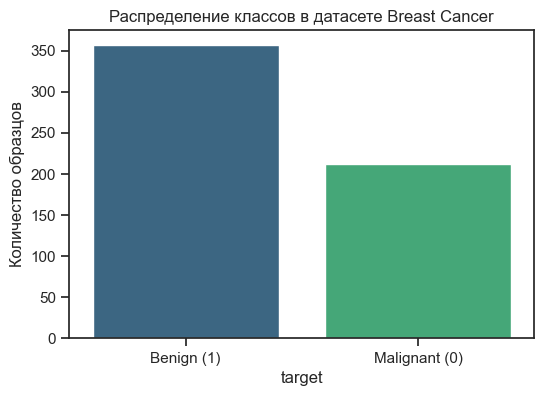

In [17]:
class_counts = df['target'].value_counts()
class_names_mapped = class_counts.index.map({0: 'Malignant (0)', 1: 'Benign (1)'})

print("Распределение классов:\n", class_counts)

plt.figure(figsize=(6, 4))
sns.barplot(
    x=class_names_mapped, 
    y=class_counts.values, 
    hue=class_names_mapped,   
    legend=False,             
    palette="viridis"
)
plt.title('Распределение классов в датасете Breast Cancer')
plt.ylabel('Количество образцов')
plt.show()

## 3. Разделение на обучающую и тестовую выборки

С помощью `train_test_split` разделим данные в соотношении 70/30.  
Параметр `stratify=y` гарантирует сохранение пропорций классов в обучающей и тестовой выборках.

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")
print(f"\nБаланс классов в обучающей выборке:\n{pd.Series(y_train).value_counts()}")
print(f"\nБаланс классов в тестовой выборке:\n{pd.Series(y_test).value_counts()}")

Размер обучающей выборки: (398, 30)
Размер тестовой выборки: (171, 30)

Баланс классов в обучающей выборке:
1    250
0    148
Name: count, dtype: int64

Баланс классов в тестовой выборке:
1    107
0     64
Name: count, dtype: int64


## 4. Обучение ансамблевых моделей

Мы обучим четыре модели в соответствии с заданием:
1.  **Random Forest (Случайный лес)** — метод бэггинга с случайным выбором признаков.
2.  **Extra Trees (Сверхслучайные деревья)** — метод бэггинга с еще большей рандомизацией.
3.  **AdaBoost** — метод бустинга, адаптивно взвешивающий слабые модели.
4.  **Gradient Boosting (Градиентный бустинг)** — метод бустинга, оптимизирующий функцию потерь.

Для воспроизводимости результатов во всех моделях зафиксирован `random_state`.

In [18]:
models = {}

# Модели группы бэггинга
models['Random Forest'] = RandomForestClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)

models['Extra Trees'] = ExtraTreesClassifier(
    n_estimators=100, random_state=42, n_jobs=-1
)

# Модели группы бустинга
models['AdaBoost'] = AdaBoostClassifier(
    n_estimators=100, random_state=42
)

models['Gradient Boosting'] = GradientBoostingClassifier(
    n_estimators=100, random_state=42
)

# Обучение всех моделей
for name, model in models.items():
    model.fit(X_train, y_train)
    print(f"Модель '{name}' успешно обучена.")

print("\nВсе модели обучены!")

Модель 'Random Forest' успешно обучена.
Модель 'Extra Trees' успешно обучена.
Модель 'AdaBoost' успешно обучена.
Модель 'Gradient Boosting' успешно обучена.

Все модели обучены!


## 5. Оценка качества моделей

Для оценки качества моделей будем использовать метрику **F1-Score**.

**Обоснование выбора метрики:**  
Датасет Breast Cancer содержит небольшой дисбаланс классов (злокачественных опухолей примерно в 1.7 раз меньше, чем доброкачественных). В медицинских задачах одинаково важны обе ошибки:
*   Ложноположительный результат (False Positive) — здорового пациента направят на дополнительное обследование.
*   Ложноотрицательный результат (False Negative) — больной пациент не получит своевременного лечения.

F1-Score является гармоническим средним между Precision и Recall, поэтому хорошо подходит для оценки качества на несбалансированных данных, где важен баланс между точностью и полнотой.

Сравним качество всех моделей на тестовой выборке по метрике F1-Score.

Сравнение моделей по метрике F1-Score:

Модель                    F1-Score  
-----------------------------------
Random Forest             0.9488    
Extra Trees               0.9770    
AdaBoost                  0.9633    
Gradient Boosting         0.9585    


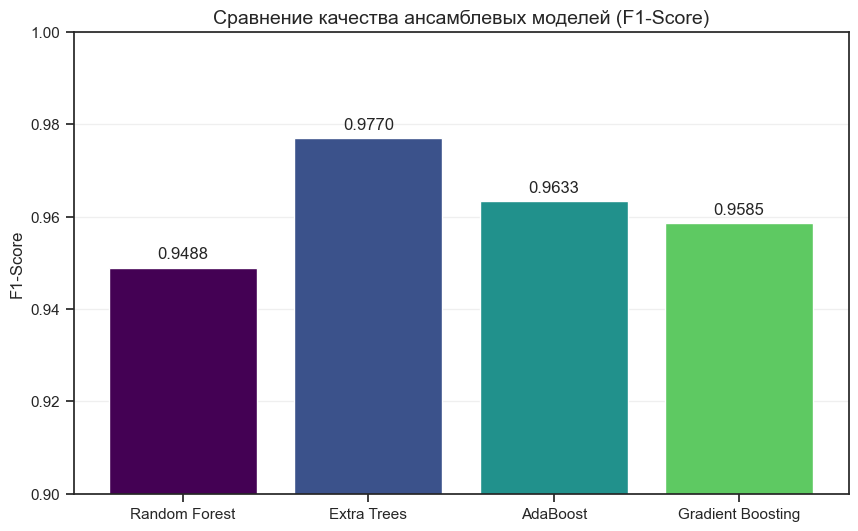


Лучшая модель: Extra Trees (F1 = 0.9770)


In [19]:

from sklearn.metrics import f1_score

print("Сравнение моделей по метрике F1-Score:\n")
print(f"{'Модель':<25} {'F1-Score':<10}")
print("-" * 35)

f1_scores = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    f1 = f1_score(y_test, y_pred)
    f1_scores[name] = f1
    print(f"{name:<25} {f1:<10.4f}")

# Построение графика сравнения
plt.figure(figsize=(10, 6))
bars = plt.bar(f1_scores.keys(), f1_scores.values(), color=['#440154', '#3b528b', '#21918c', '#5ec962'])
plt.title('Сравнение качества ансамблевых моделей (F1-Score)', fontsize=14)
plt.ylabel('F1-Score', fontsize=12)
plt.ylim(0.90, 1.0)
plt.grid(axis='y', alpha=0.3)

for bar, score in zip(bars, f1_scores.values()):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002, 
             f'{score:.4f}', ha='center', fontsize=12)

plt.show()

print(f"\nЛучшая модель: {max(f1_scores, key=f1_scores.get)} (F1 = {max(f1_scores.values()):.4f})")

## 6. Выводы по работе

В ходе лабораторной работы были обучены и сравнены четыре ансамблевые модели на датасете Breast Cancer:

1.  **Random Forest (Случайный лес)** — метод бэггинга.
2.  **Extra Trees (Сверхслучайные деревья)** — метод бэггинга.
3.  **AdaBoost** — метод бустинга.
4.  **Gradient Boosting (Градиентный бустинг)** — метод бустинга.

**Основные результаты:**

Все модели показали высокое качество классификации (F1-Score > 0.94). Рейтинг моделей по убыванию F1-Score:

| Место | Модель | F1-Score |
|-------|--------|----------|
| 1 | Extra Trees | 0.9770 |
| 2 | AdaBoost | 0.9633 |
| 3 | Gradient Boosting | 0.9585 |
| 4 | Random Forest | 0.9488 |

**Анализ результатов:**

*   **Лучший результат** показала модель **Extra Trees (F1 = 0.9770)**. Повышенная рандомизация в выборе порогов разбиения позволила построить менее коррелированные деревья и улучшить итоговое качество ансамбля.
*   **AdaBoost** неожиданно опередил градиентный бустинг (F1 = 0.9633 против 0.9585). Это объясняется хорошей работой AdaBoost с "простыми"基线-моделями (деревья глубины 1) на относительно небольшом наборе признаков.
*   **Gradient Boosting** показал третий результат (F1 = 0.9585). Возможно, качество можно улучшить подбором гиперпараметров (скорость обучения, максимальная глубина деревьев).
*   **Random Forest** показал наихудший результат среди всех моделей (F1 = 0.9488), но разница с лидером составляет всего ~0.03, что подтверждает стабильность метода.

**Вывод:**

Все ансамблевые методы успешно справились с задачей классификации опухолей молочной железы. Модель Extra Trees показала наилучший баланс между точностью и полнотой (F1 = 0.9770). На практике выбор конкретного метода зависит от требований к скорости обучения (Random Forest и Extra Trees легко параллелятся) и интерпретируемости результатов. Для повышения качества градиентного бустинга рекомендуется провести настройку гиперпараметров с помощью GridSearchCV.